## ♟ context :
In this notebook we will be implementing a neural network with python code only, meaning no pytorch or any other ml libraries.

The **Goal** is to better understand what is a neural network actually instead of just typing ready code and that will be by looking at it from a very different angle

## 📁 More Resources :

1. https://www.geeksforgeeks.org/numpy/implementation-of-neural-network-from-scratch-using-numpy/

2. https://youtu.be/CqOfi41LfDw?si=H9VWKtmkN4s2vxGr

### Activation Functions — ReLU and Sigmoid

1. Relu basically returns 0 if the input value is less than 0 else it return the value itself --> think
2. Sigmoind on the other hand follows the expression F(x) = 1 / (1 + exp(-x)) therefor 0 < F(x) < 1 no matter what is the value of x --> decide

In [1]:
import numpy as np

class Relu:
  def forward(self, x):
    self.input = x
    return np.maximum(0, x)

  def backward(self, gradient):
    return gradient * (self.input > 0)

class Sigmoid :
  def forward(self, x):
    self.output = 1 / (1 + np.exp(-x))
    return self.output

  def backward(self, gradient):
    return gradient * (self.output * (1 - self.output))

### The Layer class — forward pass computes weighted sum + activation; backward pass computes gradients w.r.t. weights, bias, and input.

In [2]:
class layer:
  def __init__(self, inputs, neurons, activation):
    self.weights = np.random.randn(inputs, neurons)*0.1 #keeps early activations from saturating
    self.bias = np.zeros((1, neurons))
    self.activation = activation

  def forward(self, x):
    self.input = x
    self.weighted_sum = np.dot(x, self.weights) + self.bias
    self.output = self.activation.forward(self.weighted_sum)
    return self.output


  def backward(self, gradient, lr):
    gradient = self.activation.backward(gradient)
    d_weights = np.dot(self.input.T, gradient)
    d_bias = np.sum(gradient, axis=0, keepdims=True)
    gradient_input = np.dot(gradient, self.weights.T)
    self.weights -= lr * d_weights
    self.bias -= lr * d_bias
    return gradient_input

### The Network — stacks layers together and chains forward/backward through all of them.

In [3]:
class Network:
  def __init__(self):
    self.layers = []

  def add(self, layer):
    self.layers.append(layer)

  def forward(self, x):
    for layer in self.layers:
      x = layer.forward(x)
    return x

  def backward(self, gradient, lr):
    for layer in reversed(self.layers):
      gradient = layer.backward(gradient, lr)

  ## Training loop — forward pass, compute MSE loss, backprop, update weights.

  def train(self, x, y, epochs, lr):
    self.loss_history = []
    for epoch in range(epochs):
      output = self.forward(x)
      loss = np.mean(np.square(output - y))
      self.loss_history.append(loss)
      gradient = 2 * (output - y) / output.shape[0]
      self.backward(gradient, lr)

      if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")
    return output

In [4]:
def main():
  np.random.seed(42)
  ### Example: XOR dataset
  X = np.array([
      [0, 0],
      [0, 1],
      [1, 0],
      [1, 1]
  ])
  y = np.array([[0],[1],[1],[0]])

  network = Network()
  network.add(layer(2, 4, Relu()))
  network.add(layer(4, 1, Sigmoid()))

  network.train(X, y, epochs=1000, lr=0.01)

  print(np.round(network.forward(X), 4))

  return network, X, y

if __name__ == "__main__":
  network, X, y = main()

Epoch 0, Loss: 0.2500807264346339
Epoch 100, Loss: 0.25005121145413617
Epoch 200, Loss: 0.2500231928927493
Epoch 300, Loss: 0.24999607074093208
Epoch 400, Loss: 0.2499692991777139
Epoch 500, Loss: 0.24994236822375387
Epoch 600, Loss: 0.24991478835274325
Epoch 700, Loss: 0.24988607722294784
Epoch 800, Loss: 0.24985574787487028
Epoch 900, Loss: 0.24982329787655977
[[0.5019]
 [0.4996]
 [0.4993]
 [0.4961]]


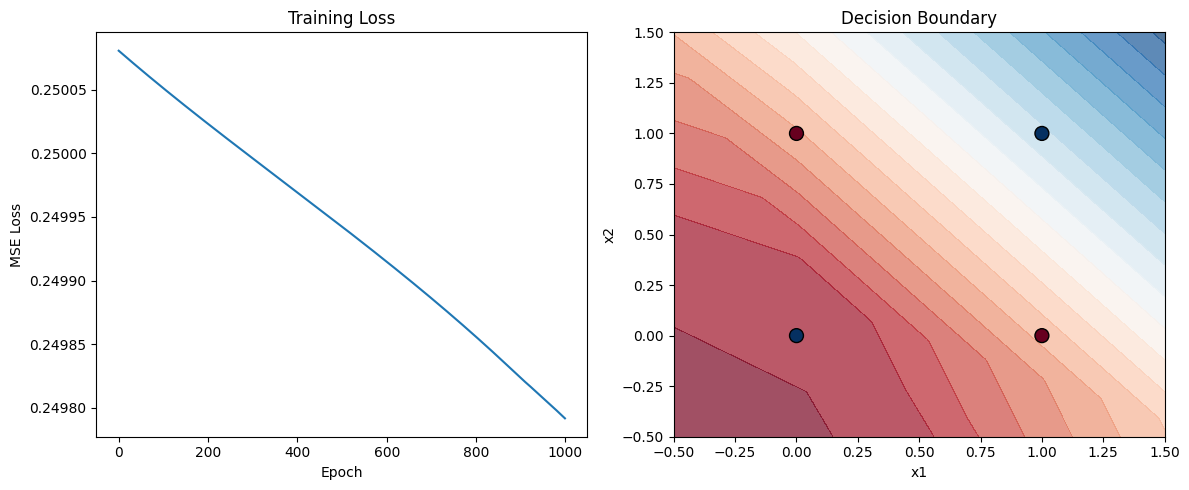

In [5]:
import matplotlib.pyplot as plt

def visualize(network, X, y):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Loss curve ---
    axes[0].plot(network.loss_history)
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")

    # --- Decision boundary ---
    # build a grid covering the input space with some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    preds = network.forward(grid).reshape(xx.shape)

    axes[1].contourf(xx, yy, preds, levels=20, cmap="RdBu_r", alpha=0.7)
    axes[1].scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="RdBu_r",
                     edgecolors="black", s=100)
    axes[1].set_title("Decision Boundary")
    axes[1].set_xlabel("x1")
    axes[1].set_ylabel("x2")

    plt.tight_layout()
    plt.show()

visualize(network, X, y)